In [94]:
import pandas as pd
import numpy as np

df = pd.read_csv("Model_data.csv")

# drop missing 
required_cols = [
    'birth_rate_per_thousand', 'weekly_hours',
    'cash_per_capita', 'maternity_per_capita', 'services_per_capita'
]
df = df.dropna(subset=required_cols).copy()


df['weekly_hours_squared'] = df['weekly_hours'] ** 2
df['weekly_hours_cubed'] = df['weekly_hours'] ** 3
df['cash_per_capita_squared'] = df['cash_per_capita'] ** 2
df['services_per_capita_squared'] = df['services_per_capita'] ** 2

# feature list
features = [
    'weekly_hours', 'cash_per_capita', 'maternity_per_capita', 'services_per_capita',
    'weekly_hours_squared', 'weekly_hours_cubed',
    'cash_per_capita_squared', 'services_per_capita_squared'
]

X_raw = df[features].values
Y = df['birth_rate_per_thousand'].values

# standardize
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_std[X_std == 0] = 1  
X_standardized = (X_raw - X_mean) / X_std
X_design = np.c_[np.ones(X_standardized.shape[0]), X_standardized]

# train using normal equation
beta = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ Y)
df['predicted_birth_rate'] = X_design @ beta

# evaluate model
mae = np.mean(np.abs(Y - df['predicted_birth_rate']))
r2 = 1 - np.sum((Y - df['predicted_birth_rate'])**2) / np.sum((Y - np.mean(Y))**2)

print("Model Evaluation:")
print(f"MAE: {mae:}")
print(f"R²:  {r2:}")

# model coefficients
feature_names = ['intercept'] + features
for name, b in zip(feature_names, beta):
    print(f"{name:} {b:}")


# EXAMPLE
mock_input = pd.DataFrame([{
    'weekly_hours': 34,
    'cash_per_capita': 1200,
    'maternity_per_capita': 600,
    'services_per_capita': 1000,
    'weekly_hours_squared': 34**2,
    'weekly_hours_cubed': 34**3,
    'cash_per_capita_squared': 1200**2,
    'services_per_capita_squared': 1000**2
}])

# Standardize new input
mock_std = (mock_input[features].values - X_mean) / X_std
mock_X = np.c_[np.ones((1,)), mock_std]
predicted_birth = mock_X @ beta

print("\nPredicted birth rate for mock input:", predicted_birth[0])


Model Evaluation:
MAE: 0.8554452972486888
R²:  0.20494214966561752
intercept 9.709569377990391
weekly_hours 43.97361741075498
cash_per_capita -1.5466764388529706
maternity_per_capita 0.7253613278930059
services_per_capita -0.6409148556442577
weekly_hours_squared -86.3538184164236
weekly_hours_cubed 41.93959752072412
cash_per_capita_squared 1.4375034265977322
services_per_capita_squared 0.27451327522306634

Predicted birth rate for mock input: 11.901159980985916


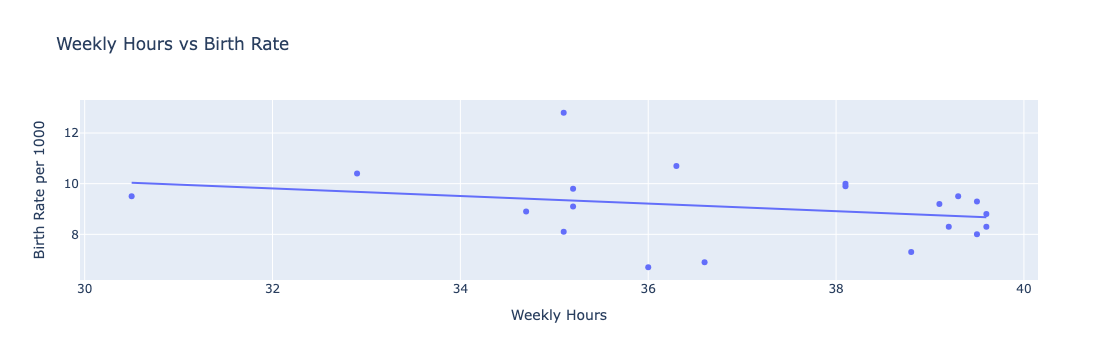

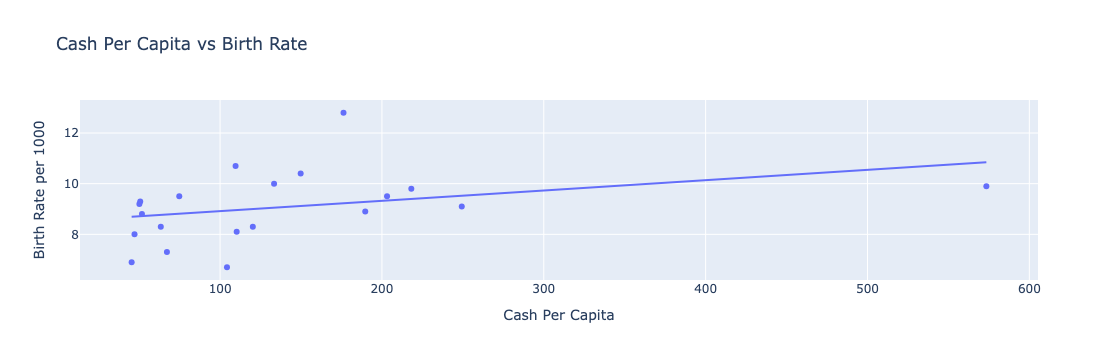

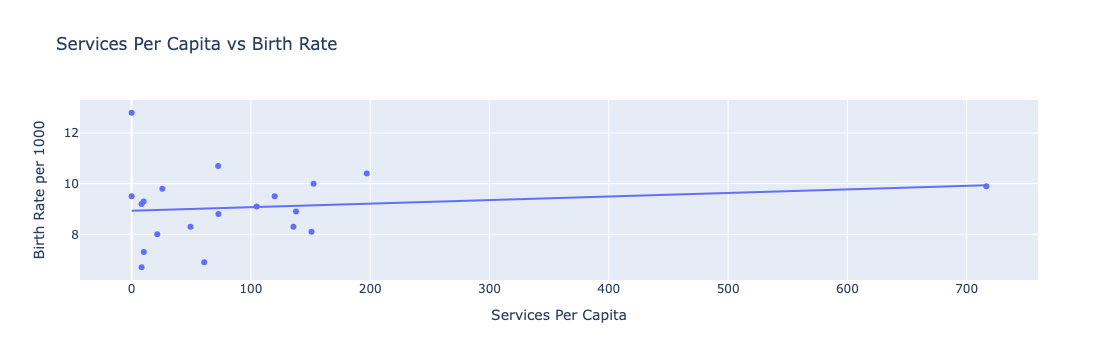

In [95]:
import pandas as pd
import plotly.express as px


df = pd.read_csv("final_cleaned.csv")

# drop missing values
df = df.dropna(subset=[
    'weekly_hours', 'cash_per_capita', 'services_per_capita', 'birth_rate_per_thousand'
])

df['year'] = pd.to_numeric(df['year'], errors='coerce')

# keep most recent year
df_filtered = df.sort_values('year').groupby('country_code', as_index=False).last()

# plot features
features = [
    'weekly_hours', 'weekly_hours_squared', 'weekly_hours_cubed',
    'cash_per_capita', 'cash_per_capita_squared', 'cash_per_capita_cubed',
    'services_per_capita', 'services_per_capita_squared', 'services_per_capita_cubed'
]

for feature in features:
    if feature in df_filtered.columns:
        fig = px.scatter(
            df_filtered,
            x=feature,
            y='birth_rate_per_thousand',
            hover_name='country_code',
            trendline='ols',
            title=f"{feature.replace('_', ' ').title()} vs Birth Rate",
            labels={
                feature: feature.replace('_', ' ').title(),
                'birth_rate_per_thousand': 'Birth Rate per 1000'
            }
        )
        fig.show()





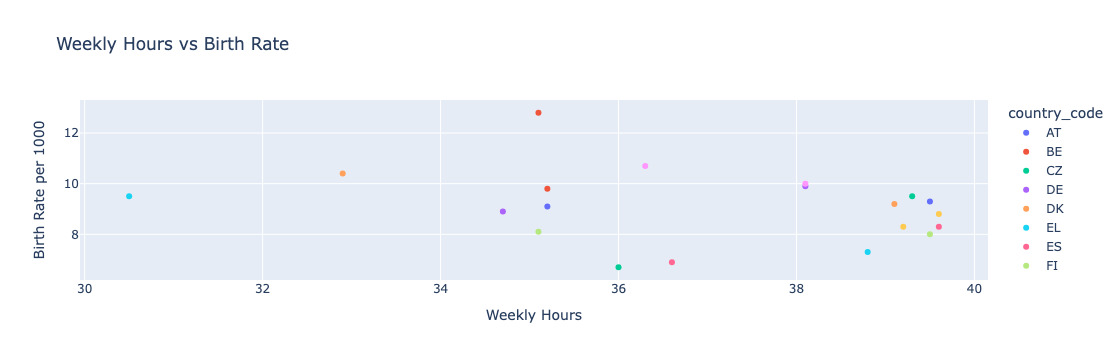

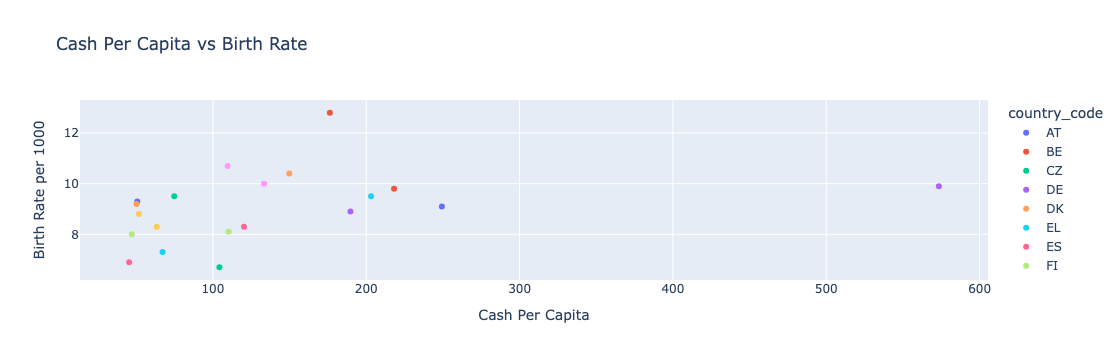

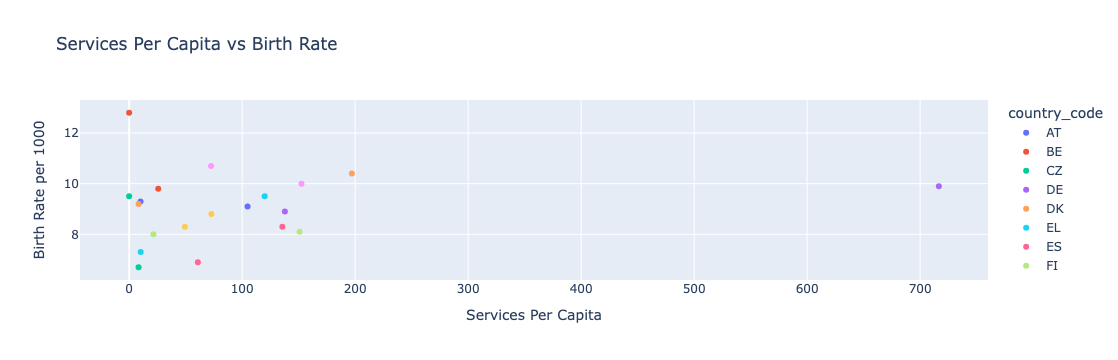

In [91]:
import pandas as pd
import plotly.express as px


df = pd.read_csv("final_cleaned.csv")


df = df.dropna(subset=[
    'weekly_hours', 'cash_per_capita', 'services_per_capita', 'birth_rate_per_thousand', 'year'
])

df['year'] = pd.to_numeric(df['year'], errors='coerce')

# group by country_code and year
df_grouped = df.groupby(['country_code', 'year'], as_index=False).mean(numeric_only=True)

# keep most recent year for country
df_latest = df_grouped.sort_values('year').groupby('country_code', as_index=False).last()

# Plot
features = [
    'weekly_hours', 'weekly_hours_squared', 'weekly_hours_cubed',
    'cash_per_capita', 'cash_per_capita_squared', 'cash_per_capita_cubed',
    'services_per_capita', 'services_per_capita_squared', 'services_per_capita_cubed'
]

for feature in features:
    if feature in df_latest.columns:
        fig = px.scatter(
            df_latest,
            x=feature,
            y='birth_rate_per_thousand',
            color='country_code',
            hover_name='country_code',
            trendline='ols',
            title=f"{feature.replace('_', ' ').title()} vs Birth Rate",
            labels={
                feature: feature.replace('_', ' ').title(),
                'birth_rate_per_thousand': 'Birth Rate per 1000'
            }
        )
        fig.show()


In [100]:
## ORGANIZED INTO FUNCTIONS
import pandas as pd
import numpy as np


# training 
def train_model(df):
    # drop rows w missing
    required_cols = [
        'birth_rate_per_thousand', 'weekly_hours',
        'cash_per_capita', 'maternity_per_capita', 'services_per_capita'
    ]
    df = df.dropna(subset=required_cols).copy()

    # add the squared/cubed 
    df['weekly_hours_squared'] = df['weekly_hours'] ** 2
    df['weekly_hours_cubed'] = df['weekly_hours'] ** 3
    df['cash_per_capita_squared'] = df['cash_per_capita'] ** 2
    df['services_per_capita_squared'] = df['services_per_capita'] ** 2

    # features + target
    features = [
        'weekly_hours', 'cash_per_capita', 'maternity_per_capita', 'services_per_capita',
        'weekly_hours_squared', 'weekly_hours_cubed',
        'cash_per_capita_squared', 'services_per_capita_squared'
    ]
    X_raw = df[features].values
    Y = df['birth_rate_per_thousand'].values

    # standardize
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0)
    X_std[X_std == 0] = 1  # avoid division by zero
    X_standardized = (X_raw - X_mean) / X_std
    X_design = np.c_[np.ones(X_standardized.shape[0]), X_standardized]  

    # train using normal equation
    beta = np.linalg.inv(X_design.T @ X_design) @ (X_design.T @ Y)

    # evaluate
    predictions = X_design @ beta
    mae = np.mean(np.abs(Y - predictions))
    r2 = 1 - np.sum((Y - predictions)**2) / np.sum((Y - np.mean(Y))**2)

    print("Model Evaluation:")
    print(f"MAE: {mae:}")
    print(f"R²:  {r2:}")

    # Print coefficients
    print("\nModel Coefficients:")
    feature_names = ['intercept'] + features
    for name, b in zip(feature_names, beta):
        print(f"{name:} {b:}")

    return beta, X_mean, X_std, features


# PREDICT
def predict_birth_rate(user_input: dict, beta, X_mean, X_std, features):
    # Build feature vector with squares and cubes
    user_df = pd.DataFrame([user_input])
    user_df['weekly_hours_squared'] = user_df['weekly_hours'] ** 2
    user_df['weekly_hours_cubed'] = user_df['weekly_hours'] ** 3
    user_df['cash_per_capita_squared'] = user_df['cash_per_capita'] ** 2
    user_df['services_per_capita_squared'] = user_df['services_per_capita'] ** 2

    # standardize
    X_input = user_df[features].values
    X_std_input = (X_input - X_mean) / X_std
    X_input_design = np.c_[np.ones((1,)), X_std_input]

    # 
    return (X_input_design @ beta)[0]


In [101]:

df = pd.read_csv("Model_data.csv")


beta, X_mean, X_std, features = train_model(df)


user_input = {
    "weekly_hours": 34,
    "cash_per_capita": 1200,
    "maternity_per_capita": 600,
    "services_per_capita": 1000
}

pred = predict_birth_rate(user_input, beta, X_mean, X_std, features)
print("\nPredicted birth rate:", pred)


Model Evaluation:
MAE: 0.8554452972486888
R²:  0.20494214966561752

Model Coefficients:
intercept 9.709569377990391
weekly_hours 43.97361741075498
cash_per_capita -1.5466764388529706
maternity_per_capita 0.7253613278930059
services_per_capita -0.6409148556442577
weekly_hours_squared -86.3538184164236
weekly_hours_cubed 41.93959752072412
cash_per_capita_squared 1.4375034265977322
services_per_capita_squared 0.27451327522306634

Predicted birth rate: 11.901159980985916


In [103]:
## STORING WEIGHTS
import pandas as pd

# Save beta (weights)
pd.DataFrame({'feature': ['intercept'] + features, 'coefficient': beta}).to_csv("model_beta.csv", index=False)

# Save mean and std
pd.DataFrame({
    'feature': features,
    'mean': X_mean,
    'std': X_std
}).to_csv("model_weights.csv", index=False)


# METADATA
standardization_df = pd.DataFrame({
    'feature': features,
    'mean': X_mean,
    'std': X_std
})

standardization_df.to_csv("model_standardization.csv", index=False)

with open("model_features.txt", "w") as f:
    for feat in features:
        f.write(f"{feat}\n")
